# INFLAÇÃO BRASIL - GERAL E GRUPOS

In [133]:
# Importação e leitura dos arquivos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ipca_anual = pd.read_csv('data/ipca_main_yearly.csv')
ipca_raw = pd.read_csv('data/ipca_full_raw.csv')
ipca_grupos = pd.read_csv('data/ipca_main_groups.csv')

In [134]:
print(ipca_anual.head())

   year                      group  value
0  2006      Alimentação e bebidas   2.56
1  2006                Comunicação  -1.68
2  2006                   Educação   0.43
3  2006                  Habitação   0.82
4  2006  Saúde e cuidados pessoais   1.76


In [135]:
print(ipca_raw.head())

         date  year  month  category_id      category  value
0  2006-07-01  2006      7         7169  Índice geral   0.19
1  2006-08-01  2006      8         7169  Índice geral   0.05
2  2006-09-01  2006      9         7169  Índice geral   0.21
3  2006-10-01  2006     10         7169  Índice geral   0.33
4  2006-11-01  2006     11         7169  Índice geral   0.31


In [136]:
print(ipca_grupos.head())

         date  year  month  category_id                 category  value  \
0  2006-07-01  2006      7         7170  1.Alimentação e bebidas   0.09   
1  2006-08-01  2006      8         7170  1.Alimentação e bebidas   0.07   
2  2006-09-01  2006      9         7170  1.Alimentação e bebidas   0.08   
3  2006-10-01  2006     10         7170  1.Alimentação e bebidas   0.88   
4  2006-11-01  2006     11         7170  1.Alimentação e bebidas   1.05   

                   group  
0  Alimentação e bebidas  
1  Alimentação e bebidas  
2  Alimentação e bebidas  
3  Alimentação e bebidas  
4  Alimentação e bebidas  


In [137]:
print(ipca_anual.info())
print("================================")
print(ipca_raw.info())
print("=================================")
print(ipca_grupos.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    120 non-null    int64  
 1   group   120 non-null    str    
 2   value   120 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 2.9 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 108138 entries, 0 to 108137
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         108138 non-null  str    
 1   year         108138 non-null  int64  
 2   month        108138 non-null  int64  
 3   category_id  108138 non-null  int64  
 4   category     108138 non-null  str    
 5   value        107186 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 5.0 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------     

In [138]:
# Validação dos dados
print("Duplicados em ipca_anual:", ipca_anual.duplicated().sum())
print("Duplicados em ipca_raw:", ipca_raw.duplicated().sum())
print("Duplicados em ipca_grupos:", ipca_grupos.duplicated().sum())

print("Valores nulos em ipca_anual:\n", ipca_anual.isnull().sum())
print("Valores nulos em ipca_raw:\n", ipca_raw.isnull().sum())
print("Valores nulos em ipca_grupos:\n", ipca_grupos.isnull().sum())

Duplicados em ipca_anual: 0
Duplicados em ipca_raw: 0
Duplicados em ipca_grupos: 0
Valores nulos em ipca_anual:
 year     0
group    0
value    0
dtype: int64
Valores nulos em ipca_raw:
 date             0
year             0
month            0
category_id      0
category         0
value          952
dtype: int64
Valores nulos em ipca_grupos:
 date           0
year           0
month          0
category_id    0
category       0
value          0
group          0
dtype: int64


In [139]:
# Valores nulos em ipca_raw motivo na coluna 'value'

null_rows = ipca_raw[ipca_raw.isnull().any(axis=1)]
print("Linhas com valores nulos em ipca_raw:")
print(null_rows)

Linhas com valores nulos em ipca_raw:
             date  year  month  category_id                 category  value
30798  2012-01-01  2012      1        41128  1101075.Feijão - branco    NaN
30799  2012-02-01  2012      2        41128  1101075.Feijão - branco    NaN
30800  2012-03-01  2012      3        41128  1101075.Feijão - branco    NaN
30801  2012-04-01  2012      4        41128  1101075.Feijão - branco    NaN
30802  2012-05-01  2012      5        41128  1101075.Feijão - branco    NaN
...           ...   ...    ...          ...                      ...    ...
65493  2018-04-01  2018      4        41131    1108170.Peixe - mandi    NaN
69510  2018-01-01  2018      1       107683       8104005.Autoescola    NaN
69511  2018-02-01  2018      2       107683       8104005.Autoescola    NaN
69512  2018-03-01  2018      3       107683       8104005.Autoescola    NaN
69513  2018-04-01  2018      4       107683       8104005.Autoescola    NaN

[952 rows x 6 columns]


In [140]:
# Analise final de validação de dados
print("Porcentagem de linhas com valores nulos em ipca_raw:", len(null_rows) / len(ipca_raw) * 100)
print("Porcentagem de linhas com valores nulos na coluna category com 'Índice geral':", len(null_rows[null_rows['category'] == 'Índice geral']) / len(ipca_raw) * 100)

Porcentagem de linhas com valores nulos em ipca_raw: 0.8803565814052415
Porcentagem de linhas com valores nulos na coluna category com 'Índice geral': 0.0


In [141]:
# Inflação total por ano
ipca_total_anual = ipca_raw[ipca_raw['category'] == 'Índice geral'].groupby('year')['value'].sum().reset_index()
ipca_total_anual = ipca_total_anual[ipca_total_anual['year'] != 2006]
ipca_total_anual

,year,value
1,2007,4.37
2,2008,5.75
3,2009,4.23
4,2010,5.76
5,2011,6.32
6,2012,5.69
7,2013,5.76
8,2014,6.23
9,2015,10.19
10,2016,6.12


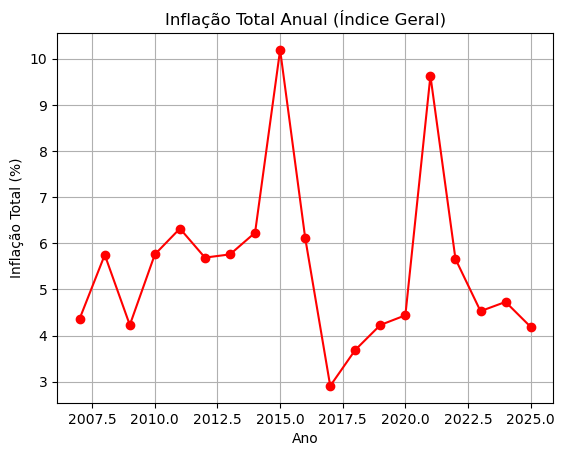

In [142]:
plt.plot(ipca_total_anual['year'], ipca_total_anual['value'], color='red', marker='o')
plt.xlabel('Ano')
plt.ylabel('Inflação Total (%)')
plt.title('Inflação Total Anual (Índice Geral)')
plt.grid()
plt.show()

In [143]:
# Menor e maior inflação anual
min_inflacao = ipca_total_anual['value'].min()
max_inflacao = ipca_total_anual['value'].max()
print(f"Menor inflação anual: {min_inflacao:.2f}%")
print(f"Maior inflação anual: {max_inflacao:.2f}%")

Menor inflação anual: 2.91%
Maior inflação anual: 10.19%


In [144]:
# Comparação média e deviação padrão entre os ultimos 10 anos e os anos anteriores
ipca_ultimos_10_anos = ipca_total_anual[ipca_total_anual['year'] >= 2016]
ipca_anteriores = ipca_total_anual[ipca_total_anual['year'] < 2016]
media_ultimos_10_anos = ipca_ultimos_10_anos['value'].mean()
media_anteriores = ipca_anteriores['value'].mean()
desvio_ultimos_10_anos = ipca_ultimos_10_anos['value'].std()
desvio_anteriores = ipca_anteriores['value'].std()
print(f"Média dos últimos 10 anos: {media_ultimos_10_anos:.2f}%")
print(f"Média dos anos anteriores: {media_anteriores:.2f}%")
print(f"Desvio padrão dos últimos 10 anos: {desvio_ultimos_10_anos:.2f}%")
print(f"Desvio padrão dos anos anteriores: {desvio_anteriores:.2f}%")

Média dos últimos 10 anos: 5.01%
Média dos anos anteriores: 6.03%
Desvio padrão dos últimos 10 anos: 1.86%
Desvio padrão dos anos anteriores: 1.72%


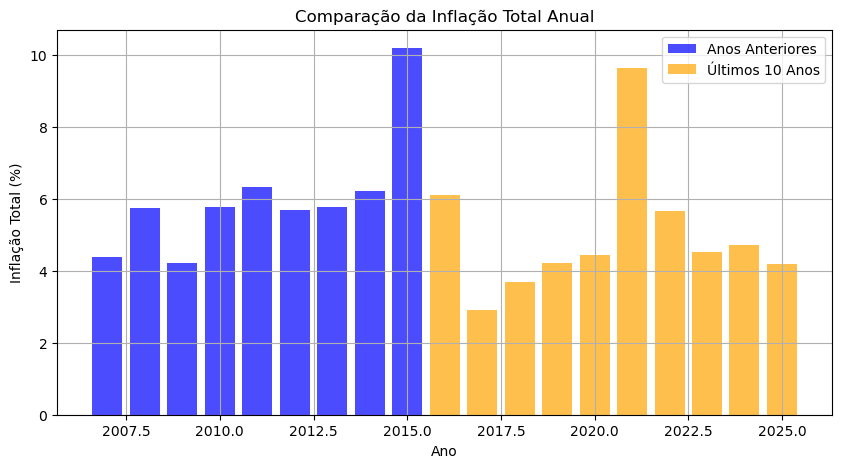

In [145]:
# Plot comparativo entre os últimos 10 anos e os anos anteriores
plt.figure(figsize=(10, 5))
plt.bar(ipca_anteriores['year'], ipca_anteriores['value'], color='blue', label='Anos Anteriores', alpha=0.7)
plt.bar(ipca_ultimos_10_anos['year'], ipca_ultimos_10_anos['value'], color='orange', label='Últimos 10 Anos', alpha=0.7)
plt.xlabel('Ano')
plt.ylabel('Inflação Total (%)')
plt.title('Comparação da Inflação Total Anual')
plt.legend()    
plt.grid()
plt.show()

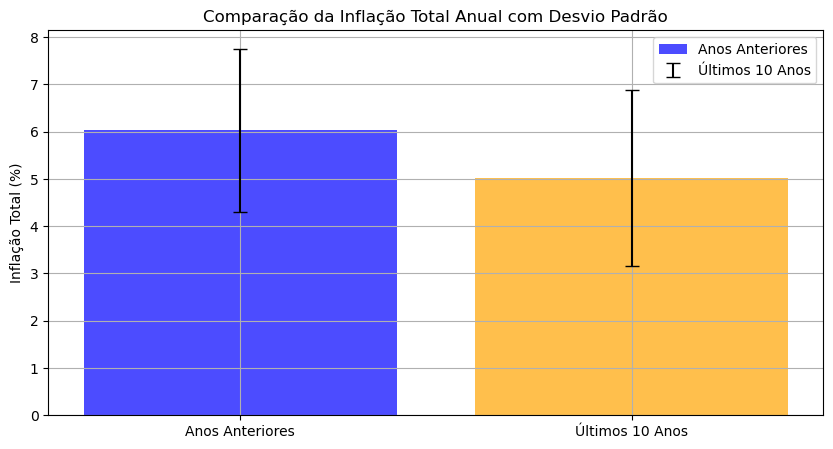

In [146]:
# Exemplo visual didatico de std
plt.figure(figsize=(10, 5))
colors = ['blue', 'orange']
plt.bar(periods, means, color=colors, alpha=0.7)
plt.errorbar(periods, means, yerr=[desvio_anteriores, desvio_ultimos_10_anos], fmt='none', ecolor='black', capsize=5)
plt.ylabel('Inflação Total (%)')
plt.title('Comparação da Inflação Total Anual com Desvio Padrão')
plt.legend(periods)
plt.grid()
plt.show()

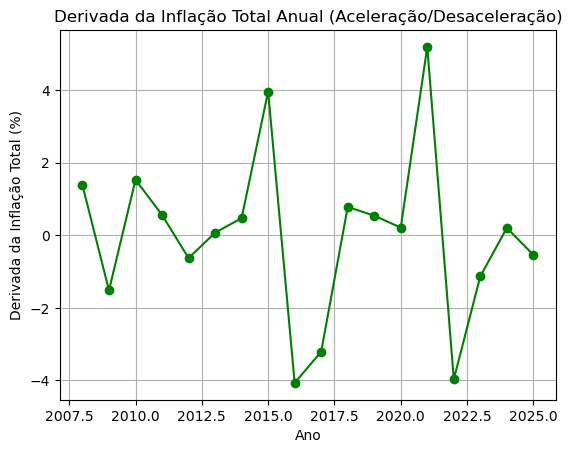

In [147]:
# Detecção de aceleração ou desaceleração da inflação com derivada
ipca_total_anual['derivada'] = ipca_total_anual['value'].diff()
plt.plot(ipca_total_anual['year'], ipca_total_anual['derivada'], color='green', marker='o')
plt.xlabel('Ano')
plt.ylabel('Derivada da Inflação Total (%)')
plt.title('Derivada da Inflação Total Anual (Aceleração/Desaceleração)')
plt.grid()
plt.show()



In [148]:
# Variabilidade da inflação nos meses por ano
ipca_mensal = ipca_raw[ipca_raw['category'] == 'Índice geral'].groupby(['year', 'month'])['value'].sum().reset_index()
variabilidade_anual = ipca_mensal.groupby('year')['value'].std().reset_index()
variabilidade_anual

,year,value
0,2006,0.146481
1,2007,0.149208
2,2008,0.170158
3,2009,0.129272
4,2010,0.307305
5,2011,0.235385
6,2012,0.194911
7,2013,0.253449
8,2014,0.241866
9,2015,0.320467


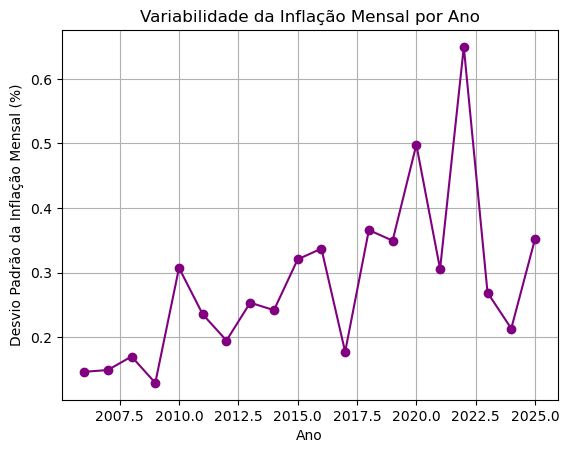

In [149]:
plt.plot(variabilidade_anual['year'], variabilidade_anual['value'], color='purple', marker='o')
plt.xlabel('Ano')
plt.ylabel('Desvio Padrão da Inflação Mensal (%)')
plt.title('Variabilidade da Inflação Mensal por Ano')
plt.grid()
plt.show()

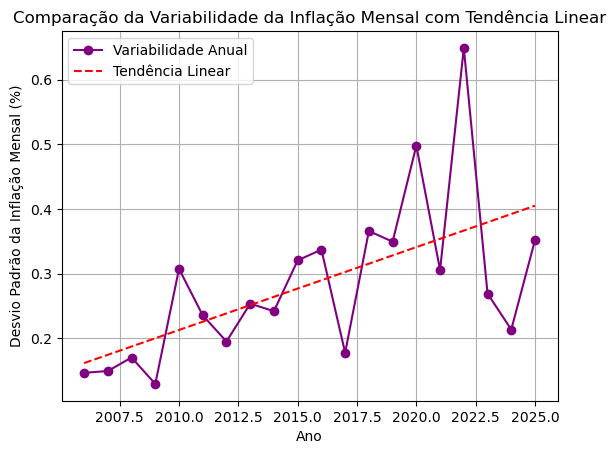

Coeficiente angular da tendência de variabilidade: 0.012818241317166853
Intercepto da tendência de variabilidade: -25.55189221158526
Correlacao entre variabilidade e ano: 0.36006423702767487


In [150]:
# Regressão linear para tendência de variabilidade de inflação
trend = model.predict(X)
plt.plot(variabilidade_anual['year'], variabilidade_anual['value'], color='purple', marker='o', label='Variabilidade Anual')
plt.plot(variabilidade_anual['year'], trend, color='red', linestyle='--', label='Tendência Linear')
plt.xlabel('Ano')
plt.ylabel('Desvio Padrão da Inflação Mensal (%)')
plt.title('Comparação da Variabilidade da Inflação Mensal com Tendência Linear')
plt.legend()
plt.grid()
plt.show() 
# Valores
print("Coeficiente angular da tendência de variabilidade:", model.coef_[0])
print("Intercepto da tendência de variabilidade:", model.intercept_)
print("Correlacao entre variabilidade e ano:", model.score(X, y))

In [151]:
# Taxa de volatilidade dos ultimos 5 anos em comparação com os anos anteriores
variabilidade_ultimos_5_anos = variabilidade_anual[variabilidade_anual['year'] >= 2021]['value'].mean()
variabilidade_anteriores = variabilidade_anual[variabilidade_anual['year'] < 2021]['value'].mean()
print(f"Variabilidade média dos últimos 5 anos: {variabilidade_ultimos_5_anos:.2f}%")
print(f"Variabilidade média dos anos anteriores: {variabilidade_anteriores:.2f}%")

Variabilidade média dos últimos 5 anos: 0.36%
Variabilidade média dos anos anteriores: 0.26%


In [160]:
# Analise por categoria de grupos
ipca_grupos_anual = ipca_grupos.groupby(['year', 'group'])['value'].sum().reset_index()
ipca_grupos_anual

,year,group,value
0,2006,Alimentação e bebidas,2.56
1,2006,Comunicação,-1.68
2,2006,Educação,0.43
3,2006,Habitação,0.82
4,2006,Saúde e cuidados pessoais,1.76
...,...,...,...
115,2025,Comunicação,2.31
116,2025,Educação,6.15
117,2025,Habitação,6.79
118,2025,Saúde e cuidados pessoais,5.46


In [161]:
# Inflacao media por categoria de grupo
ipca_grupos_media = ipca_grupos.groupby('group')['value'].mean().reset_index()
ipca_grupos_media

,group,value
0,Alimentação e bebidas,0.600726
1,Comunicação,0.096368
2,Educação,0.512393
3,Habitação,0.470470
4,Saúde e cuidados pessoais,0.496068
5,Transportes,0.349744


In [166]:
# Media geral de inflação por categoria de grupo
media_geral = ipca_grupos_media['value'].mean()
print(media_geral)

0.42096153846153844


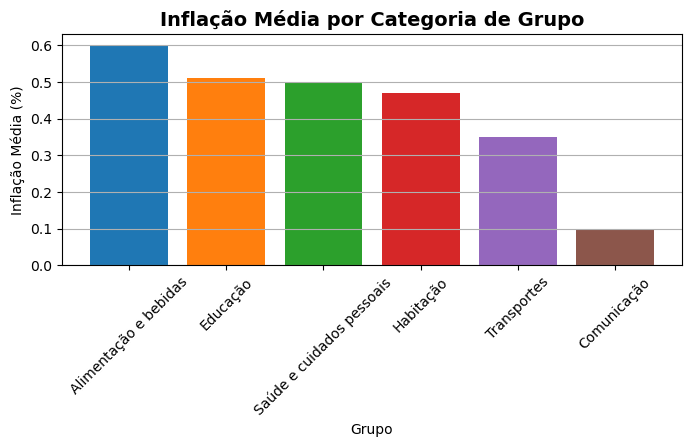

In [170]:
# Grafico
ipca_grupos_media_sorted = ipca_grupos_media.sort_values('value', ascending=False)
colors = plt.cm.tab10.colors[:len(ipca_grupos_media_sorted)]
explode = [0.1 if i == 0 else 0 for i in range(len(ipca_grupos_media_sorted))]

plt.figure(figsize=(8, 3))
plt.bar(ipca_grupos_media_sorted['group'], ipca_grupos_media_sorted['value'], color=colors)
plt.xlabel('Grupo')
plt.ylabel('Inflação Média (%)')
plt.title('Inflação Média por Categoria de Grupo', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [168]:
# Quais estão acima da média geral de inflação por categoria de grupo
acima_media = ipca_grupos_media[ipca_grupos_media['value'] > media_geral]
print("Categorias de grupo com inflação média acima da média geral:")
print(acima_media[['group', 'value']])

Categorias de grupo com inflação média acima da média geral:
                       group     value
0      Alimentação e bebidas  0.600726
2                   Educação  0.512393
3                  Habitação  0.470470
4  Saúde e cuidados pessoais  0.496068


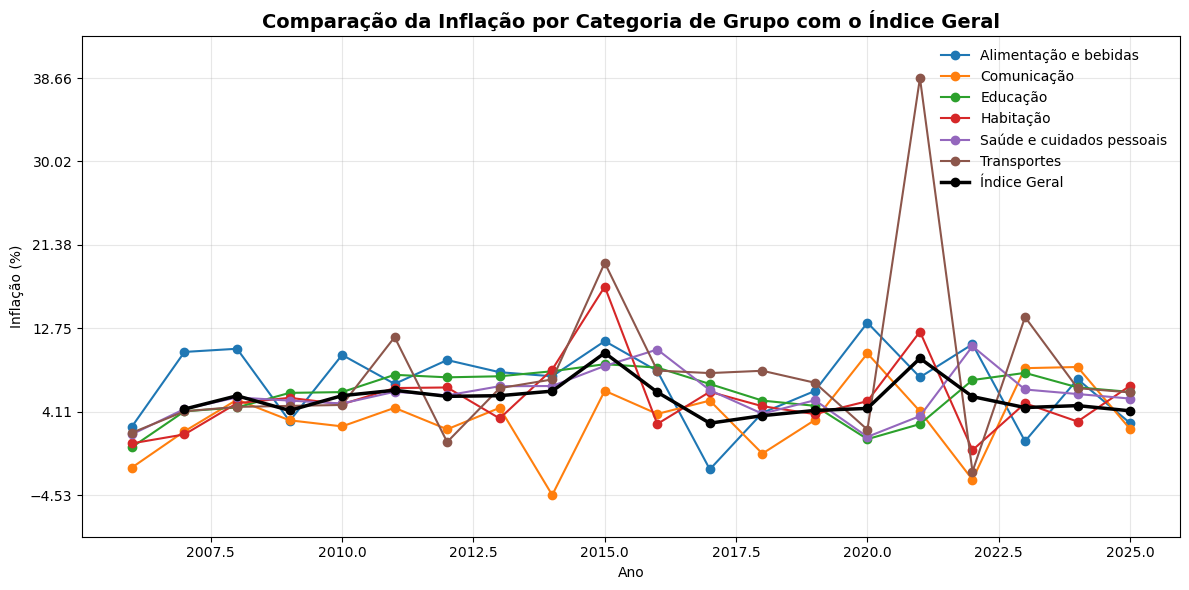

In [188]:
# Índice geral
ipca_geral = ipca_raw[ipca_raw['category'] == 'Índice geral'] \
    .groupby('year')['value'].sum().reset_index()
ipca_geral = ipca_geral[ipca_geral['year'] >= 2007]

# Categorias
ipca_categorias = ipca_grupos \
    .groupby(['year', 'group'])['value'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.title('Comparação da Inflação por Categoria de Grupo com o Índice Geral',
          fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Inflação (%)')
plt.grid(alpha=0.3)

# Linhas das categorias
for group in ipca_categorias['group'].unique():
    group_data = ipca_categorias[ipca_categorias['group'] == group]
    plt.plot(group_data['year'], group_data['value'],
             marker='o', label=group, linewidth=1.5)

# Linha do índice geral (destaque)
plt.plot(ipca_geral['year'], ipca_geral['value'],
         color='black', marker='o', linewidth=2.5, label='Índice Geral')

# Ajuste de escala (principal melhoria)
y_min = min(ipca_categorias['value'].min(), ipca_geral['value'].min())
y_max = max(ipca_categorias['value'].max(), ipca_geral['value'].max())
margem = (y_max - y_min) * 0.1

plt.ylim(y_min - margem, y_max + margem)

# Ticks mais inteligentes
plt.yticks(np.linspace(y_min, y_max, 6))

# Legenda e layout
plt.legend(frameon=False)
plt.tight_layout()

plt.show()

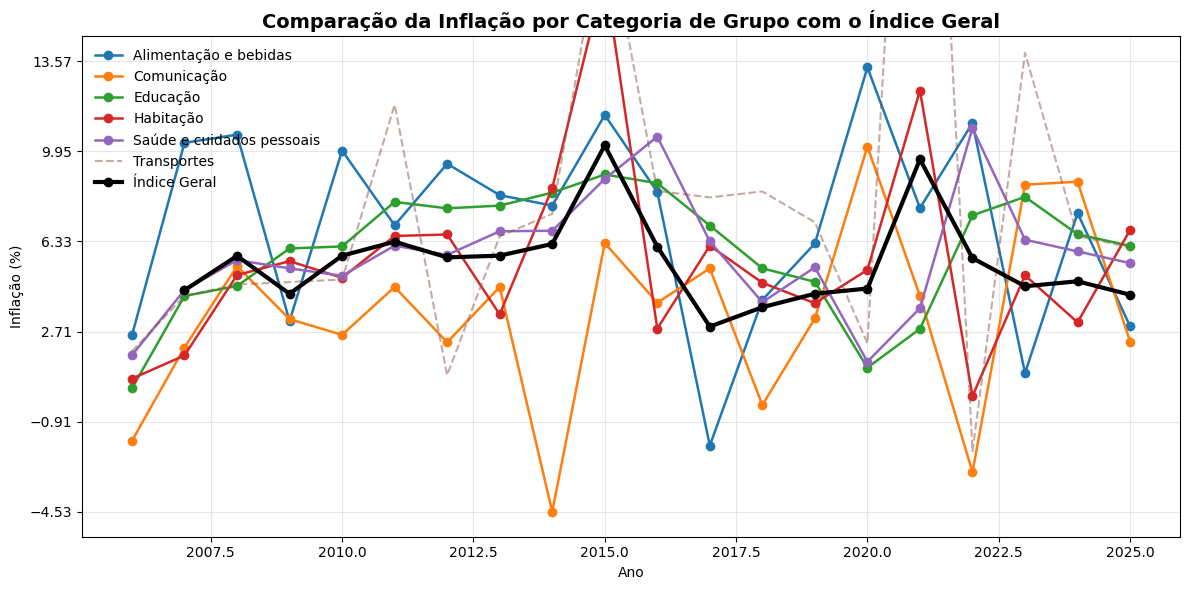

In [186]:
# Índice geral
ipca_geral = ipca_raw[ipca_raw['category'] == 'Índice geral'] \
    .groupby('year')['value'].sum().reset_index()
ipca_geral = ipca_geral[ipca_geral['year'] >= 2007]

# Categorias
ipca_categorias = ipca_grupos \
    .groupby(['year', 'group'])['value'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.title('Comparação da Inflação por Categoria de Grupo com o Índice Geral',
          fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Inflação (%)')
plt.grid(alpha=0.3)

# 🔥 Plot com controle visual inteligente
for group in ipca_categorias['group'].unique():
    group_data = ipca_categorias[ipca_categorias['group'] == group]
    
    if group == 'Transportes':
        # 👇 reduz impacto visual do outlier
        plt.plot(group_data['year'], group_data['value'],
                 linestyle='--', alpha=0.5, linewidth=1.5, label=group)
    else:
        plt.plot(group_data['year'], group_data['value'],
                 marker='o', linewidth=1.8, label=group)

# Índice geral destacado
plt.plot(ipca_geral['year'], ipca_geral['value'],
         color='black', marker='o', linewidth=3, label='Índice Geral')

# 🔥 Limite de eixo mais inteligente (sem cortar brutalmente)
y_min = ipca_categorias['value'].min()
y_max = np.percentile(ipca_categorias['value'], 97)  # corta só extremos absurdos

plt.ylim(y_min - 1, y_max + 1)

# Ticks suaves
plt.yticks(np.linspace(y_min, y_max, 6))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

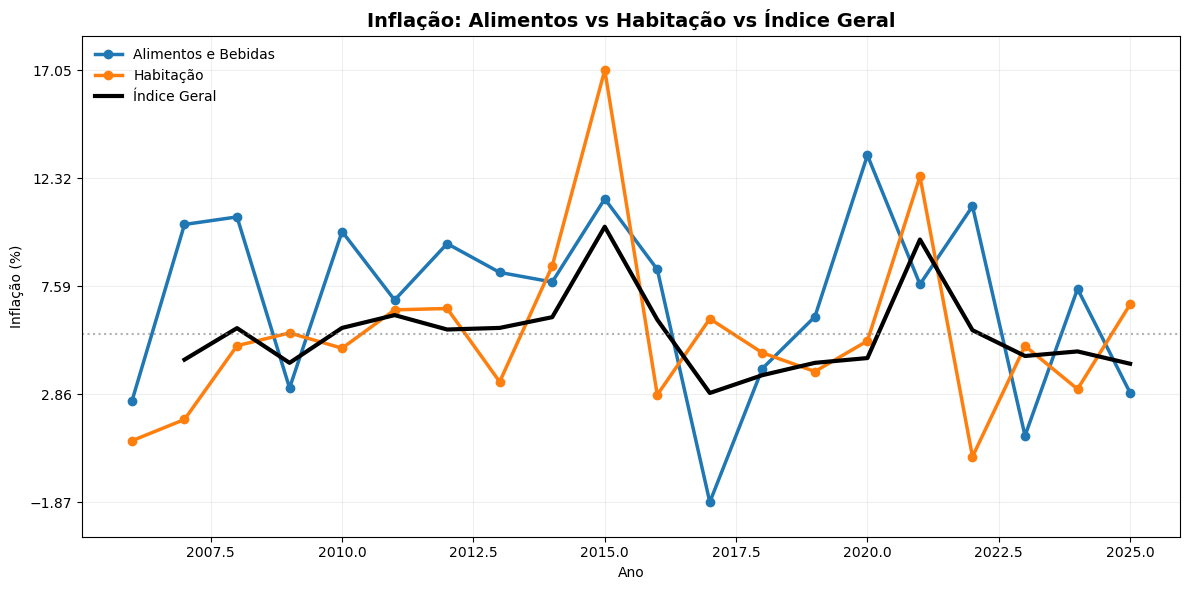

In [196]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Dados
# ---------------------------
ipca_alimentos = ipca_categorias[ipca_categorias['group'] == 'Alimentação e bebidas'].copy()
ipca_habitacao = ipca_categorias[ipca_categorias['group'] == 'Habitação'].copy()
ipca_geral = ipca_geral.copy()

# ---------------------------
# 🔥 Limpeza (evita erro de NaN/Inf)
# ---------------------------
for df in [ipca_alimentos, ipca_habitacao, ipca_geral]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['value'], inplace=True)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12, 6))
plt.title('Inflação: Alimentos vs Habitação vs Índice Geral',
          fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Inflação (%)')
plt.grid(alpha=0.2)

# Linhas
plt.plot(ipca_alimentos['year'], ipca_alimentos['value'],
         marker='o', linewidth=2.5, label='Alimentos e Bebidas')

plt.plot(ipca_habitacao['year'], ipca_habitacao['value'],
         marker='o', linewidth=2.5, label='Habitação')

plt.plot(ipca_geral['year'], ipca_geral['value'],
         color='black', linewidth=3, label='Índice Geral')

# Linha média do IPCA
plt.axhline(ipca_geral['value'].mean(),
            color='gray', linestyle=':', alpha=0.6)

# ---------------------------
# 🔥 Escala segura (sem NaN/Inf)
# ---------------------------
values = np.concatenate([
    ipca_alimentos['value'].values,
    ipca_habitacao['value'].values,
    ipca_geral['value'].values
])

values = values[np.isfinite(values)]

y_min = values.min()
y_max = values.max()

margem = (y_max - y_min) * 0.08

plt.ylim(y_min - margem, y_max + margem)
plt.yticks(np.linspace(y_min, y_max, 5))

# Legenda
plt.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()